### Import and Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from matplotlib.patches import Patch
import pkg_resources


In [2]:
df =  pd.read_csv('data/student_habits_performance.csv')
df

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


### Description and Data Cleaning

In [3]:
# Display basic information
print("Dataset Shape (Rows, Columns):", df.shape)
print("\nFirst 5 rows of the dataset:")
df.head() 

Dataset Shape (Rows, Columns): (1000, 16)

First 5 rows of the dataset:


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
# Check the last few rows to see if there's consistency
print("\nLast 5 rows of the dataset:")
df.tail()


Last 5 rows of the dataset:


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7
999,S1999,19,Female,4.3,2.9,1.9,No,89.4,7.1,Good,2,Bachelor,Average,8,No,74.9


In [5]:
# Check column names and data types
print("\nDataset Information:")
df.info() 

# Alternative way to check data types
print("\nData Types of Each Column:")
df.dtypes


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality           

student_id                        object
age                                int64
gender                            object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating               int64
extracurricular_participation     object
exam_score                       float64
dtype: object

In [6]:
# Get descriptive statistics for numerical columns
print("\nDescriptive Statistics for Numerical Columns:")
df.describe()


Descriptive Statistics for Numerical Columns:


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [7]:
# Check for missing values
print("Missing Values in Each Column:")
df.isnull().sum()

# Calculate percentage of missing values
missing_percentage = df.isnull().mean()*100
print("\nPercentage of Missing Values:")
print(missing_percentage)

Missing Values in Each Column:

Percentage of Missing Values:
student_id                       0.0
age                              0.0
gender                           0.0
study_hours_per_day              0.0
social_media_hours               0.0
netflix_hours                    0.0
part_time_job                    0.0
attendance_percentage            0.0
sleep_hours                      0.0
diet_quality                     0.0
exercise_frequency               0.0
parental_education_level         9.1
internet_quality                 0.0
mental_health_rating             0.0
extracurricular_participation    0.0
exam_score                       0.0
dtype: float64


In [8]:
# For parental_education_level (categorical), fill with mode (most common value)
df['parental_education_level'].fillna(df['parental_education_level'].mode()[0], inplace=True)

# Verify missing values are handled
print("Missing Values After Handling:")
print(df.isnull().sum())

Missing Values After Handling:
student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64


In [9]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of Duplicate Rows: {duplicate_count}")

# Remove duplicates if any
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicate_count} duplicate rows")
    print(f"New dataset shape: {df.shape}")
else:
    print("No duplicate rows found")

Number of Duplicate Rows: 0
No duplicate rows found


In [10]:
# Check for inconsistent data in categorical columns
print("Unique values in categorical columns:")

categorical_columns = ['student_id', 'gender', 'part_time_job', 'diet_quality', 
                       'parental_education_level', 'internet_quality', 'extracurricular_participation']

for col in categorical_columns:
    print(f"\n{col} unique values")
    
    # Print first 10 unique values if there are many
    if df[col].nunique() > 10:
        print(f"  First 10: {df[col].unique()[:10]}")
    else:
        print(df[col].unique())


Unique values in categorical columns:

student_id unique values
  First 10: ['S1000' 'S1001' 'S1002' 'S1003' 'S1004' 'S1005' 'S1006' 'S1007' 'S1008'
 'S1009']

gender unique values
['Female' 'Male' 'Other']

part_time_job unique values
['No' 'Yes']

diet_quality unique values
['Fair' 'Good' 'Poor']

parental_education_level unique values
['Master' 'High School' 'Bachelor']

internet_quality unique values
['Average' 'Poor' 'Good']

extracurricular_participation unique values
['Yes' 'No']


In [11]:
df.drop(axis = 1, columns = ['student_id'], inplace =(True))
df

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


### Features Engineering

In [12]:
# 1. ENCODE BINARY COLUMNS
binary_map = {"yes": 1, "no": 0, True: 1, False: 0}

df["has_job"] = df["part_time_job"].str.lower().map(binary_map).astype(int)
df["extracurricular_attendance"] = (df["extracurricular_participation"].str.lower().map(binary_map).astype(int))
print(df)

     age  gender  study_hours_per_day  social_media_hours  netflix_hours  \
0     23  Female                  0.0                 1.2            1.1   
1     20  Female                  6.9                 2.8            2.3   
2     21    Male                  1.4                 3.1            1.3   
3     23  Female                  1.0                 3.9            1.0   
4     19  Female                  5.0                 4.4            0.5   
..   ...     ...                  ...                 ...            ...   
995   21  Female                  2.6                 0.5            1.6   
996   17  Female                  2.9                 1.0            2.4   
997   20    Male                  3.0                 2.6            1.3   
998   24    Male                  5.4                 4.1            1.1   
999   19  Female                  4.3                 2.9            1.9   

    part_time_job  attendance_percentage  sleep_hours diet_quality  \
0              No

In [13]:
 # 2. ENCODE ORDINAL COLUMNS
gender_map = {"male": 0, "female": 1, "other": 2}
df["gender_encoded"] = df["gender"].str.lower().map(gender_map)
 
diet_map = {"poor": 0, "fair": 1, "good": 2}
df["diet_encoded"] = df["diet_quality"].str.lower().map(diet_map)
 
internet_map = {"poor": 0, "average": 1, "good": 2}
df["internet_level"] = df["internet_quality"].str.lower().map(internet_map)
 
edu_map = {
    "none": 0,
    "high school": 1,
    "bachelor": 2,
    "master": 3,
    "phd": 4,
}
df["parent_edu_level"] = df["parental_education_level"].str.lower().map(edu_map)
print(df)

     age  gender  study_hours_per_day  social_media_hours  netflix_hours  \
0     23  Female                  0.0                 1.2            1.1   
1     20  Female                  6.9                 2.8            2.3   
2     21    Male                  1.4                 3.1            1.3   
3     23  Female                  1.0                 3.9            1.0   
4     19  Female                  5.0                 4.4            0.5   
..   ...     ...                  ...                 ...            ...   
995   21  Female                  2.6                 0.5            1.6   
996   17  Female                  2.9                 1.0            2.4   
997   20    Male                  3.0                 2.6            1.3   
998   24    Male                  5.4                 4.1            1.1   
999   19  Female                  4.3                 2.9            1.9   

    part_time_job  attendance_percentage  sleep_hours diet_quality  \
0              No

In [14]:
# 3. TRANSFORM NUMERIC COLUMNS
    # Age group bins
df["age_group"] = pd.cut(df["age"],bins=[0, 20, 23, 100],labels=["18-20", "21-23", "24+"],)

    # Sleep: quality label + deficit from optimal 8h
df["sleep_quality"] = pd.cut(df["sleep_hours"],bins=[0, 5, 7, 24],labels=["deprived", "ok", "optimal"])
 
    # Attendance
df["attendance_group"] = pd.cut(df["attendance_percentage"],bins=[0, 60, 80, 100],labels=["low", "medium", "high"],)
df

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,...,exam_score,has_job,extracurricular_attendance,gender_encoded,diet_encoded,internet_level,parent_edu_level,age_group,sleep_quality,attendance_group
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,...,56.2,0,1,1,1,1,3,21-23,optimal,high
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,...,100.0,0,0,1,2,1,1,18-20,deprived,high
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,...,34.3,0,0,0,0,0,1,21-23,optimal,high
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,...,26.8,0,1,1,0,2,3,21-23,optimal,medium
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,...,66.4,0,0,1,1,2,3,18-20,deprived,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,...,76.1,0,1,1,1,2,1,21-23,optimal,medium
996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,...,65.9,1,1,1,0,1,1,18-20,ok,high
997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,...,64.4,0,1,0,2,2,2,18-20,ok,medium
998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,...,69.7,1,0,0,1,1,2,24+,optimal,high


In [15]:
 # 4. COMPOSITE / INTERACTION FEATURES
# Total passive screen time
df["total_distraction_hours"] = (df["social_media_hours"] + df["netflix_hours"])
 
    # Study efficiency relative to sleep
df["study_efficiency"] = df["study_hours_per_day"] / df["sleep_hours"].replace(0, np.nan)
df["study_efficiency"] = df["study_efficiency"].fillna(0)
 
    # Productive hours = study × attendance weight
df["productive_hours"] = (df["study_hours_per_day"] * (df["attendance_percentage"] / 100))
 
    # Wellness score: diet + exercise + sleep (each normalised to [0,1])
scaler = MinMaxScaler()
wellness_raw = df[["diet_encoded", "exercise_frequency", "sleep_hours"]].copy()
df["wellness_score"] = scaler.fit_transform(wellness_raw).mean(axis=1)
 
df

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,...,diet_encoded,internet_level,parent_edu_level,age_group,sleep_quality,attendance_group,total_distraction_hours,study_efficiency,productive_hours,wellness_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,...,1,1,3,21-23,optimal,high,2.3,0.000000,0.0000,0.735294
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,...,2,1,1,18-20,deprived,high,5.1,1.500000,6.7137,0.735294
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,...,0,0,1,21-23,optimal,high,4.4,0.175000,1.3272,0.290850
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,...,0,2,3,21-23,optimal,medium,4.9,0.108696,0.7100,0.516340
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,...,1,2,3,18-20,deprived,high,4.9,1.020408,4.5450,0.416667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,...,1,2,1,21-23,optimal,medium,2.1,0.346667,2.0020,0.488562
996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,...,0,1,1,18-20,ok,high,3.4,0.426471,2.4940,0.232026
997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,...,2,2,2,18-20,ok,medium,3.9,0.461538,1.8570,0.772876
998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,...,1,1,2,24+,optimal,high,5.2,0.710526,5.4000,0.382353


In [16]:

df['focus_score'] = df['productive_hours'] / (df['total_distraction_hours'] + 1)
df['health_study'] = df['wellness_score'] * df['study_efficiency']

In [17]:
raw_cols_to_drop = [
    "age",
    "part_time_job",
    "extracurricular_participation",
    "diet_quality",
    "internet_quality",
    "parental_education_level",
    "social_media_hours",
    "netflix_hours",
    "sleep_deficit",
    "study_hours_per_day",
]
df = df.drop(columns=raw_cols_to_drop, errors="ignore")
df

,gender,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,has_job,extracurricular_attendance,gender_encoded,diet_encoded,...,parent_edu_level,age_group,sleep_quality,attendance_group,total_distraction_hours,study_efficiency,productive_hours,wellness_score,focus_score,health_study
0,Female,85.0,8.0,6,8,56.2,0,1,1,1,...,3,21-23,optimal,high,2.3,0.000000,0.0000,0.735294,0.000000,0.000000
1,Female,97.3,4.6,6,8,100.0,0,0,1,2,...,1,18-20,deprived,high,5.1,1.500000,6.7137,0.735294,1.100607,1.102941
2,Male,94.8,8.0,1,1,34.3,0,0,0,0,...,1,21-23,optimal,high,4.4,0.175000,1.3272,0.290850,0.245778,0.050899
3,Female,71.0,9.2,4,1,26.8,0,1,1,0,...,3,21-23,optimal,medium,4.9,0.108696,0.7100,0.516340,0.120339,0.056124
4,Female,90.9,4.9,3,1,66.4,0,0,1,1,...,3,18-20,deprived,high,4.9,1.020408,4.5450,0.416667,0.770339,0.425170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Female,77.0,7.5,2,6,76.1,0,1,1,1,...,1,21-23,optimal,medium,2.1,0.346667,2.0020,0.488562,0.645806,0.169368
996,Female,86.0,6.8,1,6,65.9,1,1,1,0,...,1,18-20,ok,high,3.4,0.426471,2.4940,0.232026,0.566818,0.098952
997,Male,61.9,6.5,5,9,64.4,0,1,0,2,...,2,18-20,ok,medium,3.9,0.461538,1.8570,0.772876,0.378980,0.356712
998,Male,100.0,7.6,0,1,69.7,1,0,0,1,...,2,24+,optimal,high,5.2,0.710526,5.4000,0.382353,0.870968,0.271672


In [18]:
raw_cols_to_drop2 = [
    "attendance_percentage",
    "sleep_hours",
    "exercise_frequency",
    "diet_encoded",
    "gender",
]
df = df.drop(columns=raw_cols_to_drop2, errors="ignore")
df

,mental_health_rating,exam_score,has_job,extracurricular_attendance,gender_encoded,internet_level,parent_edu_level,age_group,sleep_quality,attendance_group,total_distraction_hours,study_efficiency,productive_hours,wellness_score,focus_score,health_study
0,8,56.2,0,1,1,1,3,21-23,optimal,high,2.3,0.000000,0.0000,0.735294,0.000000,0.000000
1,8,100.0,0,0,1,1,1,18-20,deprived,high,5.1,1.500000,6.7137,0.735294,1.100607,1.102941
2,1,34.3,0,0,0,0,1,21-23,optimal,high,4.4,0.175000,1.3272,0.290850,0.245778,0.050899
3,1,26.8,0,1,1,2,3,21-23,optimal,medium,4.9,0.108696,0.7100,0.516340,0.120339,0.056124
4,1,66.4,0,0,1,2,3,18-20,deprived,high,4.9,1.020408,4.5450,0.416667,0.770339,0.425170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,6,76.1,0,1,1,2,1,21-23,optimal,medium,2.1,0.346667,2.0020,0.488562,0.645806,0.169368
996,6,65.9,1,1,1,1,1,18-20,ok,high,3.4,0.426471,2.4940,0.232026,0.566818,0.098952
997,9,64.4,0,1,0,2,2,18-20,ok,medium,3.9,0.461538,1.8570,0.772876,0.378980,0.356712
998,1,69.7,1,0,0,1,2,24+,optimal,high,5.2,0.710526,5.4000,0.382353,0.870968,0.271672


In [19]:
sleep_map = {"deprived": 0, "ok": 1, "optimal": 2}
df["sleep_quality"] = df["sleep_quality"].str.lower().map(sleep_map)

attendance_map = {"low": 0, "medium": 1, "high": 2}
df["attendance_group"] = df["attendance_group"].str.lower().map(attendance_map)

In [20]:
df

,mental_health_rating,exam_score,has_job,extracurricular_attendance,gender_encoded,internet_level,parent_edu_level,age_group,sleep_quality,attendance_group,total_distraction_hours,study_efficiency,productive_hours,wellness_score,focus_score,health_study
0,8,56.2,0,1,1,1,3,21-23,2,2,2.3,0.000000,0.0000,0.735294,0.000000,0.000000
1,8,100.0,0,0,1,1,1,18-20,0,2,5.1,1.500000,6.7137,0.735294,1.100607,1.102941
2,1,34.3,0,0,0,0,1,21-23,2,2,4.4,0.175000,1.3272,0.290850,0.245778,0.050899
3,1,26.8,0,1,1,2,3,21-23,2,1,4.9,0.108696,0.7100,0.516340,0.120339,0.056124
4,1,66.4,0,0,1,2,3,18-20,0,2,4.9,1.020408,4.5450,0.416667,0.770339,0.425170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,6,76.1,0,1,1,2,1,21-23,2,1,2.1,0.346667,2.0020,0.488562,0.645806,0.169368
996,6,65.9,1,1,1,1,1,18-20,1,2,3.4,0.426471,2.4940,0.232026,0.566818,0.098952
997,9,64.4,0,1,0,2,2,18-20,1,1,3.9,0.461538,1.8570,0.772876,0.378980,0.356712
998,1,69.7,1,0,0,1,2,24+,2,2,5.2,0.710526,5.4000,0.382353,0.870968,0.271672


In [21]:

features = [
        "mental_health_rating","exam_score",
    "has_job","extracurricular_attendance",
    "gender_encoded","internet_level",
    "parent_edu_level","age_group","sleep_quality",
    "attendance_group","total_distraction_hours"
    ,"study_efficiency","productive_hours",
    "wellness_score","focus_score","health_study"
]
custom_order = [
     "age_group", "mental_health_rating",
    "has_job","extracurricular_attendance",
    "gender_encoded","internet_level",
    "parent_edu_level","sleep_quality",
    "attendance_group","total_distraction_hours"
    ,"study_efficiency","productive_hours",
    "wellness_score","focus_score","health_study","exam_score"
]

df = df[custom_order] 

# Print the new order
print("New feature order:")
for i, f in enumerate(custom_order, 1):
    print(f"  {i:>2}. {f}")


New feature order:
   1. age_group
   2. mental_health_rating
   3. has_job
   4. extracurricular_attendance
   5. gender_encoded
   6. internet_level
   7. parent_edu_level
   8. sleep_quality
   9. attendance_group
  10. total_distraction_hours
  11. study_efficiency
  12. productive_hours
  13. wellness_score
  14. focus_score
  15. health_study
  16. exam_score


In [22]:
df

,age_group,mental_health_rating,has_job,extracurricular_attendance,gender_encoded,internet_level,parent_edu_level,sleep_quality,attendance_group,total_distraction_hours,study_efficiency,productive_hours,wellness_score,focus_score,health_study,exam_score
0,21-23,8,0,1,1,1,3,2,2,2.3,0.000000,0.0000,0.735294,0.000000,0.000000,56.2
1,18-20,8,0,0,1,1,1,0,2,5.1,1.500000,6.7137,0.735294,1.100607,1.102941,100.0
2,21-23,1,0,0,0,0,1,2,2,4.4,0.175000,1.3272,0.290850,0.245778,0.050899,34.3
3,21-23,1,0,1,1,2,3,2,1,4.9,0.108696,0.7100,0.516340,0.120339,0.056124,26.8
4,18-20,1,0,0,1,2,3,0,2,4.9,1.020408,4.5450,0.416667,0.770339,0.425170,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21-23,6,0,1,1,2,1,2,1,2.1,0.346667,2.0020,0.488562,0.645806,0.169368,76.1
996,18-20,6,1,1,1,1,1,1,2,3.4,0.426471,2.4940,0.232026,0.566818,0.098952,65.9
997,18-20,9,0,1,0,2,2,1,1,3.9,0.461538,1.8570,0.772876,0.378980,0.356712,64.4
998,24+,1,1,0,0,1,2,2,2,5.2,0.710526,5.4000,0.382353,0.870968,0.271672,69.7


### Exploratory Data Analysis

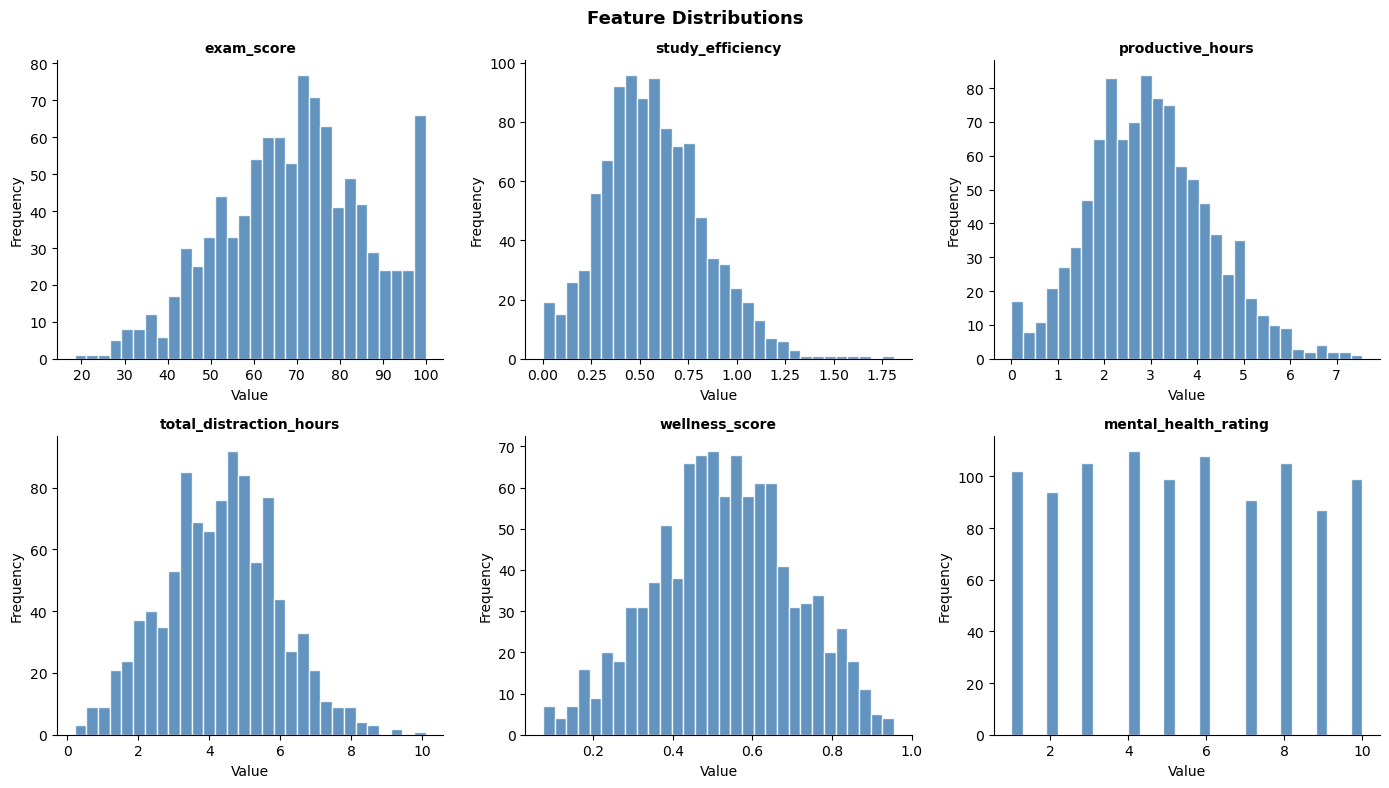

In [23]:
#Distributions
num_features = ['exam_score', 'study_efficiency', 'productive_hours',
                'total_distraction_hours', 'wellness_score', 'mental_health_rating']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for ax, col in zip(axes, num_features):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.spines[['top', 'right']].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

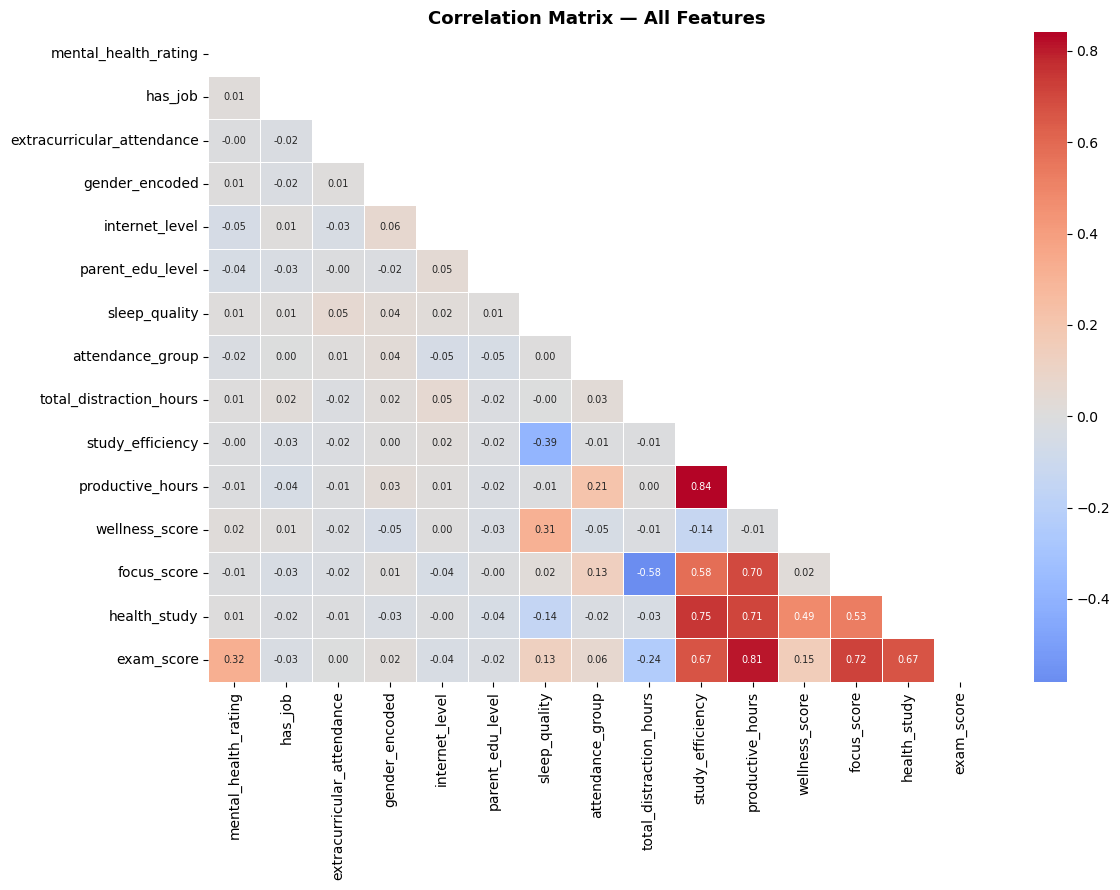

In [24]:
#Correlation matrix
plt.figure(figsize=(12, 9))
corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Matrix — All Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

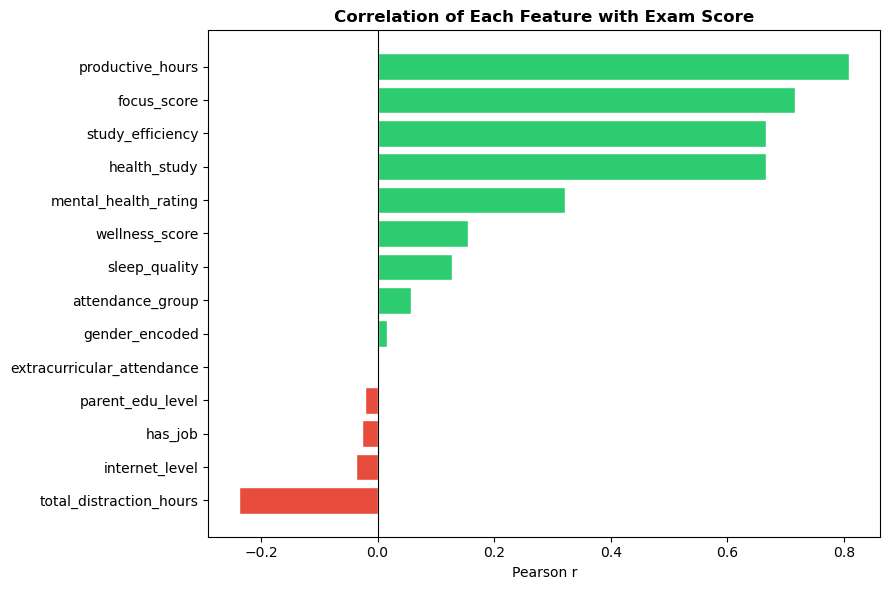

total_distraction_hours      -0.237631
internet_level               -0.036298
has_job                      -0.026608
parent_edu_level             -0.021647
extracurricular_attendance    0.000881
gender_encoded                0.016006
attendance_group              0.057875
sleep_quality                 0.127228
wellness_score                0.154677
mental_health_rating          0.321523
health_study                  0.666189
study_efficiency              0.666199
focus_score                   0.715943
productive_hours              0.809390
Name: exam_score, dtype: float64


In [25]:
#  Correlations with exam_score
corr_with_score = (df.corr(numeric_only=True)['exam_score']
                     .drop('exam_score').sort_values())
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_score]

plt.figure(figsize=(9, 6))
plt.barh(corr_with_score.index, corr_with_score.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson r')
plt.title('Correlation of Each Feature with Exam Score', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(corr_with_score)

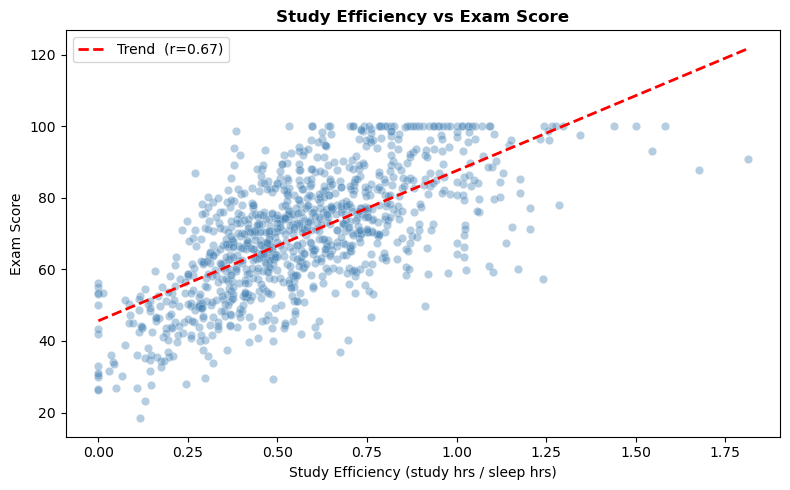

In [26]:
# Scatter: study_efficiency vs exam_score
plt.figure(figsize=(8, 5))
plt.scatter(df['study_efficiency'], df['exam_score'],
            alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.3)
m, b = np.polyfit(df['study_efficiency'].fillna(0), df['exam_score'], 1)
x_line = np.linspace(df['study_efficiency'].min(), df['study_efficiency'].max(), 100)
r_val = df['study_efficiency'].corr(df['exam_score'])
plt.plot(x_line, m * x_line + b, 'r--', linewidth=2, label=f'Trend  (r={r_val:.2f})')
plt.xlabel('Study Efficiency (study hrs / sleep hrs)')
plt.ylabel('Exam Score')
plt.title('Study Efficiency vs Exam Score', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


### STATISTICAL ANALYSIS

In [27]:
#  Exam score summary
print('=== Exam Score Summary ===')
print(df['exam_score'].describe().round(2))
print(f'\nSkewness : {df["exam_score"].skew():.3f}')
print(f'Kurtosis : {df["exam_score"].kurt():.3f}')

=== Exam Score Summary ===
count    1000.00
mean       69.60
std        16.89
min        18.40
25%        58.48
50%        70.50
75%        81.32
max       100.00
Name: exam_score, dtype: float64

Skewness : -0.156
Kurtosis : -0.420


In [28]:
#  Ranked correlations
print('\n=== Feature Correlations with exam_score (sorted) ===')
ranked = (df.corr(numeric_only=True)['exam_score']
            .drop('exam_score').sort_values(ascending=False))
for feat, val in ranked.items():
    bar  = '█' * int(abs(val) * 30)
    sign = '+' if val >= 0 else '-'
    print(f'  {feat:<28} {sign}{abs(val):.3f}  {bar}')


=== Feature Correlations with exam_score (sorted) ===
  productive_hours             +0.809  ████████████████████████
  focus_score                  +0.716  █████████████████████
  study_efficiency             +0.666  ███████████████████
  health_study                 +0.666  ███████████████████
  mental_health_rating         +0.322  █████████
  wellness_score               +0.155  ████
  sleep_quality                +0.127  ███
  attendance_group             +0.058  █
  gender_encoded               +0.016  
  extracurricular_attendance   +0.001  
  parent_edu_level             -0.022  
  has_job                      -0.027  
  internet_level               -0.036  █
  total_distraction_hours      -0.238  ███████


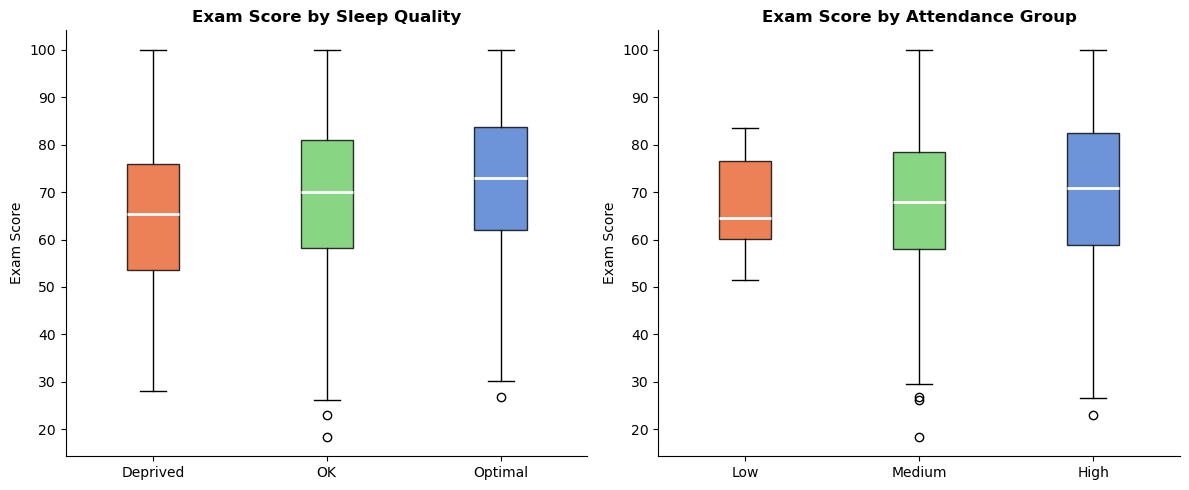

In [29]:
# Boxplots: sleep_quality and attendance_group
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sleep_labels  = {0: 'Deprived', 1: 'OK', 2: 'Optimal'}
attend_labels = {0: 'Low', 1: 'Medium', 2: 'High'}

for ax, col, label_map, title in zip(
        axes,
        ['sleep_quality', 'attendance_group'],
        [sleep_labels, attend_labels],
        ['Exam Score by Sleep Quality', 'Exam Score by Attendance Group']
):
    groups = [df.loc[df[col] == k, 'exam_score'].dropna() for k in sorted(label_map)]
    bp = ax.boxplot(groups, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2))
    colors_bp = ['#e8602c', '#6acc65', '#4878cf']
    for patch, c in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)
    ax.set_xticklabels(list(label_map.values()))
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Exam Score')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Regression 

In [30]:
object_cols = ['age_group']

label_encoders = {}
for col in object_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("All columns are numeric:")
print(df.dtypes)
print(f"\nDataset shape after cleaning: {df.shape}")

All columns are numeric:
age_group                       int64
mental_health_rating            int64
has_job                         int64
extracurricular_attendance      int64
gender_encoded                  int64
internet_level                  int64
parent_edu_level                int64
sleep_quality                   int64
attendance_group                int64
total_distraction_hours       float64
study_efficiency              float64
productive_hours              float64
wellness_score                float64
focus_score                   float64
health_study                  float64
exam_score                    float64
dtype: object

Dataset shape after cleaning: (1000, 16)


In [31]:
features_reg= [
    'study_efficiency',
    'productive_hours',
    'wellness_score',
    'mental_health_rating',
    'attendance_group',
    'sleep_quality',
    'total_distraction_hours',
    'has_job',
    'extracurricular_attendance',
    'focus_score',    
    'health_study',  ]

X_reg= df[features_reg]
y_reg= df['exam_score']

In [32]:
X_train_reg,X_test_reg,y_train_reg,y_test_reg= train_test_split(X_reg,y_reg, test_size=0.2, random_state=42)

In [33]:
X_train_reg.shape

(800, 11)

In [34]:
X_test_reg.shape

(200, 11)

In [35]:
scaler=StandardScaler()
X_train_reg_scaled= scaler.fit_transform(X_train_reg)
X_test_reg_scaled= scaler.transform(X_test_reg)

In [36]:
lr=LinearRegression()
lr.fit(X_train_reg_scaled, y_train_reg)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
y_pred= lr.predict(X_test_reg_scaled)

In [38]:
y_test_reg.values

array([ 64.2,  72.7,  79. ,  79.5,  58.2,  53.4,  70.8,  62.5,  36.8,
        67.6,  53. , 100. ,  58.4,  74.6,  28. ,  55.7,  73.8,  75.5,
        71.8,  59.4,  51.5,  69.3,  36. ,  81.8,  66.3,  71.5,  74. ,
        59.6,  66.7,  59.9,  73.7,  83.5,  70.7,  83.3,  59.8,  42.2,
        71.6,  52.5,  71.4,  97.1,  50.3,  87.9,  70.1,  70.9,  93.8,
        71.4,  57.4,  80.2,  63.8,  62.6,  61.8,  44.3,  65.1,  77.2,
        43.7,  70.6,  71.3,  63.3,  63.7,  50.7,  86.2,  68.1,  72.2,
        47.1,  72.8,  37.4,  76.3,  87.9,  59.7,  77.1,  60.4,  73.9,
        42. ,  51.3,  74.2,  73.5, 100. ,  82.3,  75.4,  75.4,  64.2,
        66.5,  77.8,  62.2,  64.1,  67.1,  69.7,  80.6,  59.2,  23.1,
        96.8,  58.6,  44.1,  48.5,  64.4,  78.4,  96.6,  73.4,  77.6,
        87.8,  63.5,  70.4,  66.1,  64.5,  45.8,  35.3,  53.4,  45.7,
        50.1,  77.2,  77. ,  85.4,  80.9,  80.6,  79.2,  70.7,  96.2,
        43.5,  82.5,  94.9,  46.8,  71.1,  83.3,  70.9,  53.8,  70.3,
        70.5,  63.1,

In [39]:
mse= mean_squared_error(y_test_reg, y_pred)
rmse= np.sqrt(mse)
r2= r2_score(y_test_reg, y_pred)

print(f"Linear Regresssion Results:")
print(f"RMSE: {rmse:,.0f}")
print(f"R²:{r2:.4f}")

Linear Regresssion Results:
RMSE: 6
R²:0.8393


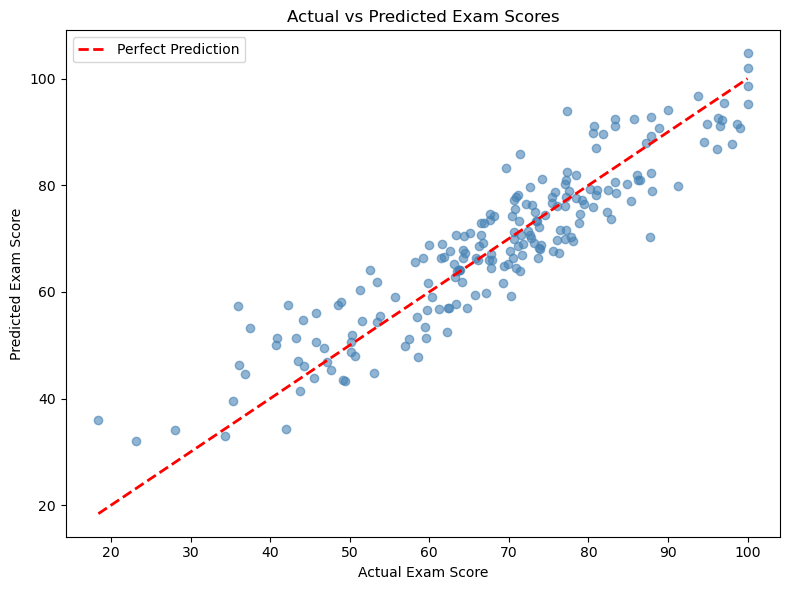

In [40]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_test_reg.min(), y_test_reg.max()], 
         [y_test_reg.min(), y_test_reg.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Scores')
plt.legend()
plt.tight_layout()
plt.show()

### Clustering

In [41]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn. decomposition import PCA
from sklearn.metrics import silhouette_score

In [42]:
raw_cols_to_drop3 = ["productive_intensity"]
df = df.drop(columns=raw_cols_to_drop3, errors="ignore")
df

,age_group,mental_health_rating,has_job,extracurricular_attendance,gender_encoded,internet_level,parent_edu_level,sleep_quality,attendance_group,total_distraction_hours,study_efficiency,productive_hours,wellness_score,focus_score,health_study,exam_score
0,1,8,0,1,1,1,3,2,2,2.3,0.000000,0.0000,0.735294,0.000000,0.000000,56.2
1,0,8,0,0,1,1,1,0,2,5.1,1.500000,6.7137,0.735294,1.100607,1.102941,100.0
2,1,1,0,0,0,0,1,2,2,4.4,0.175000,1.3272,0.290850,0.245778,0.050899,34.3
3,1,1,0,1,1,2,3,2,1,4.9,0.108696,0.7100,0.516340,0.120339,0.056124,26.8
4,0,1,0,0,1,2,3,0,2,4.9,1.020408,4.5450,0.416667,0.770339,0.425170,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,6,0,1,1,2,1,2,1,2.1,0.346667,2.0020,0.488562,0.645806,0.169368,76.1
996,0,6,1,1,1,1,1,1,2,3.4,0.426471,2.4940,0.232026,0.566818,0.098952,65.9
997,0,9,0,1,0,2,2,1,1,3.9,0.461538,1.8570,0.772876,0.378980,0.356712,64.4
998,2,1,1,0,0,1,2,2,2,5.2,0.710526,5.4000,0.382353,0.870968,0.271672,69.7


In [43]:
cluster_features = ['study_efficiency',
    'productive_hours',
    'wellness_score',
    'mental_health_rating',
    'attendance_group',
    'sleep_quality',
    'total_distraction_hours',
    'focus_score']

In [44]:
X_cluster = StandardScaler().fit_transform(df[cluster_features].fillna(0))

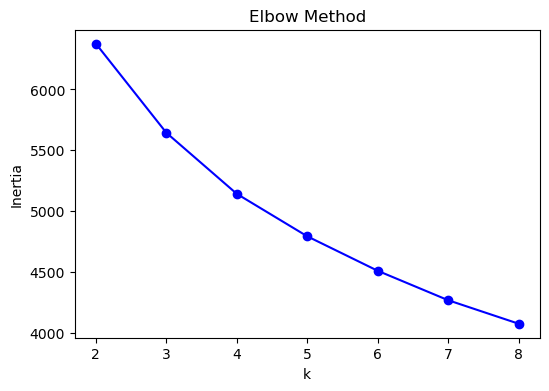

In [45]:
# Elbow method
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster).inertia_ for k in range(2, 9)]
plt.figure(figsize=(6, 4))
plt.plot(range(2, 9), inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [46]:
df['cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_cluster)
print(df.groupby('cluster')[cluster_features].mean().round(2))
df.groupby('cluster')[cluster_features].mean().round(2)

         study_efficiency  productive_hours  wellness_score  \
cluster                                                       
0                    0.49              2.33            0.55   
1                    0.36              2.18            0.53   
2                    0.71              4.17            0.57   
3                    0.87              4.07            0.45   

         mental_health_rating  attendance_group  sleep_quality  \
cluster                                                          
0                        5.48              0.97           1.25   
1                        5.47              2.00           1.34   
2                        5.32              1.85           1.43   
3                        5.44              1.85           0.66   

         total_distraction_hours  focus_score  
cluster                                        
0                           4.41         0.46  
1                           4.70         0.40  
2                           2.74

,study_efficiency,productive_hours,wellness_score,mental_health_rating,attendance_group,sleep_quality,total_distraction_hours,focus_score
cluster,,,,,,,,
0,0.49,2.33,0.55,5.48,0.97,1.25,4.41,0.46
1,0.36,2.18,0.53,5.47,2.00,1.34,4.70,0.40
2,0.71,4.17,0.57,5.32,1.85,1.43,2.74,1.20
3,0.87,4.07,0.45,5.44,1.85,0.66,4.98,0.70


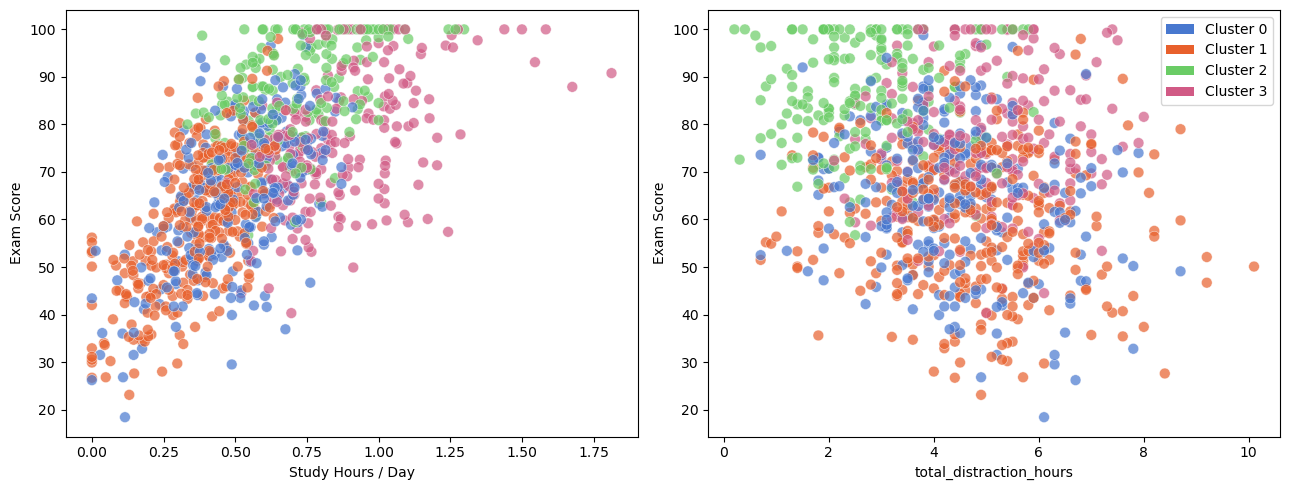

In [47]:
# Scatter plots
palette = ['#4878cf','#e8602c','#6acc65','#d15a85']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, x_col, xlabel in zip(axes,
    ['study_efficiency', 'total_distraction_hours'],
    ['Study Hours / Day', 'total_distraction_hours']):
    ax.scatter(df[x_col], df['exam_score'],
               c=[palette[c] for c in df['cluster']],
               alpha=0.7, edgecolors='white', linewidth=0.4, s=60)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Exam Score')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(facecolor=palette[i], label=f'Cluster {i}') for i in range(4)])
plt.tight_layout()
plt.show()

### Visualisation with clusters

In [48]:
palette = ['#4878cf', '#e8602c', '#6acc65', '#d15a85']
cluster_labels = {
    0: 'C0 · Low efficiency (64.9)',
    1: 'C1 · Balanced (81.6)',
    2: 'C2 · Struggling (52.7)',
    3: 'C3 · High output (81.5)'
}

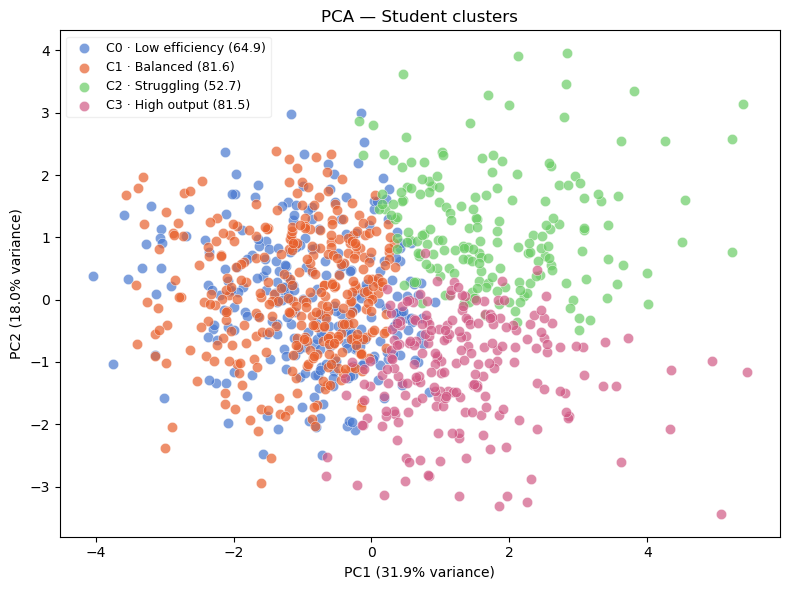

In [49]:
# ── PCA ──────────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_cluster)
var = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(8, 6))
for c in range(4):
    mask = df['cluster'] == c
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=palette[c], alpha=0.7, s=55,
               edgecolors='white', linewidth=0.4, label=cluster_labels[c])

ax.set_xlabel(f'PC1 ({var[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var[1]:.1f}% variance)')
ax.set_title('PCA — Student clusters')
ax.legend(fontsize=9, framealpha=0.3)
plt.tight_layout()
plt.show()



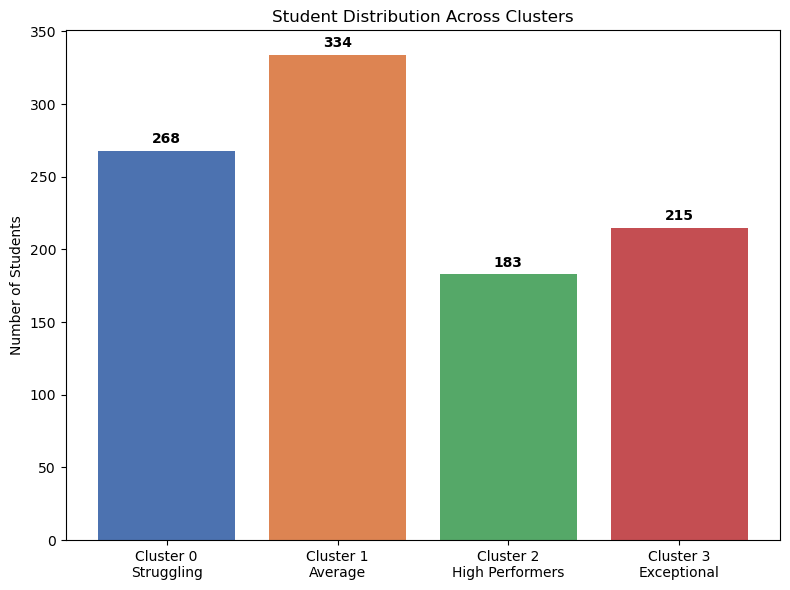

In [51]:
import matplotlib.pyplot as plt

labels = ['Cluster 0\nStruggling', 'Cluster 1\nAverage', 
          'Cluster 2\nHigh Performers', 'Cluster 3\nExceptional']
sizes = [268, 334, 183, 215]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(8, 6))
plt.bar(labels, sizes, color=colors)
plt.title('Student Distribution Across Clusters')
plt.ylabel('Number of Students')
for i, v in enumerate(sizes):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

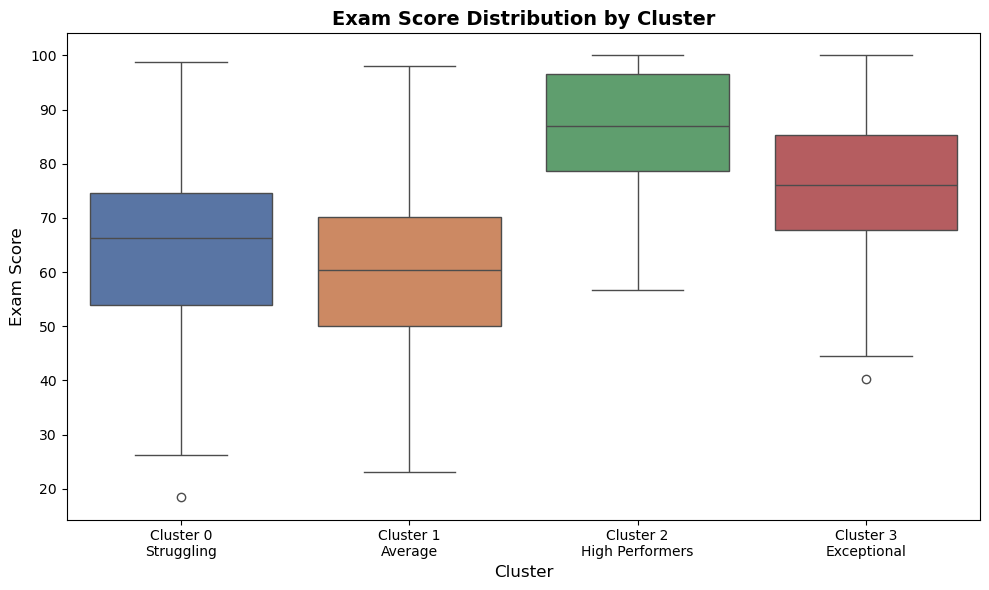

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(
    x='cluster', 
    y='exam_score', 
    data=df,
    palette=['#4C72B0', '#DD8452', '#55A868', '#C44E52']
)

plt.title('Exam Score Distribution by Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.xticks([0, 1, 2, 3], [
    'Cluster 0\nStruggling', 
    'Cluster 1\nAverage', 
    'Cluster 2\nHigh Performers', 
    'Cluster 3\nExceptional'
])
plt.tight_layout()
plt.show()